In [1]:
import os
import numpy as np
import pandas as pd
import nltk
import yake
import torch
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import string
import gc

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from joblib import Parallel, delayed
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument
from sklearn.feature_extraction.text import TfidfVectorizer
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from scipy.linalg import fractional_matrix_power
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, GATConv

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

In [2]:

STOP_WORDS = set(stopwords.words("english"))


In [3]:
df_train = pd.read_csv("data/train.csv", on_bad_lines="skip", delimiter=";")
# df_test = pd.read_csv("data/test.csv", on_bad_lines="skip", delimiter=";")
df_eval = pd.read_csv("data/evaluation.csv", on_bad_lines="skip", delimiter=";")

df = pd.concat([df_train, df_eval], ignore_index=True)

del df_train
# del df_test
del df_eval

In [4]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [5]:
df.dropna(inplace=True)
df["title"] = df["title"].str.cat(df["text"], sep=" ")

df.rename(columns={"title": "full_text"}, inplace=True)

df["binary_label"] = np.where(df["label"].isin(["fake", "1", 1]), 1, 0)
df.drop(columns=["label", "text", "Unnamed: 0"], inplace=True)

df.reset_index(drop=True, inplace=True)

In [6]:
def preprocess(input: str):

    if not isinstance(input, str):
        return ""
    input = input.lower() 
    
    input = input.translate(str.maketrans('', '', string.punctuation)) 

    t = word_tokenize(input) 
    t = [w for w in t if w not in STOP_WORDS]  
    l = WordNetLemmatizer()
    return ' '.join([l.lemmatize(w) for w in t])

In [7]:
parallel = Parallel(n_jobs=os.cpu_count(), backend="loky")
df["full_text"] = parallel(delayed(preprocess)(input) for input in df["full_text"])

In [8]:

df.to_csv("data/processed.csv", index=False)
del df

In [9]:
def evaluation_metrics(
    y_true, y_pred, y_proba=None, title=None, labels=["real", "fake"]
):
    print(f"\n{title}")
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()
    plt.title(title)
    plt.show()
    if y_proba is not None:
        roc_auc = roc_auc_score(y_true, y_proba)
        pr_auc = average_precision_score(y_true, y_proba)
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"PR-AUC: {pr_auc:.4f}")
    print("\n")


def clear_gpu_cache():
    with torch.no_grad():
        torch.cuda.empty_cache()



class KAFNData:
    def __init__(
        self,
        csv_path,
        random_state=42,
        fraction_fake_labeled=0.3,
        test_size=0.2,
    ):
        self.fraction_fake_labeled = fraction_fake_labeled
        df = pd.read_csv(csv_path, on_bad_lines="skip")

        train_df, test_df = train_test_split(
            df,
            test_size=test_size,
            stratify=df["binary_label"],
            random_state=random_state,
        )
        self.df_all = pd.concat([train_df, test_df], ignore_index=True)
        self.df_all["split"] = "test"
        self.df_all.loc[self.df_all.index[: len(train_df)], "split"] = "train"
        self.num_docs = len(self.df_all)

        self.df_all["pu_label"] = -1

        train_fake_inds = self.df_all.index[
            (self.df_all["split"] == "train") & (self.df_all["binary_label"] == 1)
        ].tolist()
        n_label = int(fraction_fake_labeled * len(train_fake_inds))
        if n_label < 1 and len(train_fake_inds) > 0:
            n_label = 1
        if len(train_fake_inds) > 0:
            labeled_inds = np.random.choice(
                train_fake_inds, size=n_label, replace=False
            )
            self.df_all.loc[labeled_inds, "pu_label"] = 1

    def get_doc_text(self, idx):
        return self.df_all.iloc[idx]["full_text"]

    def get_pu_label(self, idx):
        return self.df_all.iloc[idx]["pu_label"]

    def get_binary_label(self, idx):
        return self.df_all.iloc[idx]["binary_label"]

    def is_train_doc(self, idx):
        return self.df_all.iloc[idx]["split"] == "train"

    def is_test_doc(self, idx):
        return self.df_all.iloc[idx]["split"] == "test"


def baseline(data: KAFNData):

    train_df = data.df_all[data.df_all["split"] == "train"]
    X_tr = train_df["full_text"]
    y_tr = train_df["pu_label"].apply(lambda x: 1 if x == 1 else 0)

    test_df = data.df_all[data.df_all["split"] == "test"]
    X_tst = test_df["full_text"]
    y_tst = test_df["binary_label"]

    pipeline = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english",
                    max_features=5000, 
                    ngram_range=(1, 2), 
                ),
            ),
            (
                "classifier",
                MultinomialNB(
                    class_prior=[0.5, 0.5]
                ), 
            ),
        ]
    )
    pipeline.fit(X_tr, y_tr)
    y_pr = pipeline.predict(X_tst)

    proba = pipeline.predict_proba(X_tst)
    y_proba = proba[:, 1] if proba.shape[1] > 1 else proba[:, 0]

    title = f"=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction {data.fraction_fake_labeled} ==="
    evaluation_metrics(y_tst, y_pr, y_proba, title=title)



class Doc2VecEmb:
    def __init__(self, vector_size=100, window=5, min_count=2, epochs=20, workers=4):

        self.model = None
        self.vsize = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs
        self.workers = workers

    def train(self, data: KAFNData):
        docs = []
        for i in range(data.num_docs):
            tokens = word_tokenize(data.get_doc_text(i).lower())
            docs.append(TaggedDocument(tokens, [i]))

        model = Doc2Vec(
            documents=docs,
            vector_size=self.vsize,
            window=self.window,
            min_count=self.min_count,
            epochs=self.epochs,
            workers=self.workers,
        )
        self.model = model

    def get_vector(self, i):
        return self.model.dv[i]


class TFIDFEmb:

    def __init__(
        self, max_features=10000, ngram_range=(1, 1), min_df=1, stop_words="english"
    ):
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df,
            stop_words=stop_words,
        )
        self.doc_vectors = None 

    def train(self, data):
        texts = [data.get_doc_text(i) for i in range(data.num_docs)]
        tfidf_matrix = self.vectorizer.fit_transform(
            texts
        )  
        self.doc_vectors = tfidf_matrix.toarray()

    def get_vector(self, i):
        return self.doc_vectors[i]


def build_doc_graph(data: KAFNData, emb_model: Doc2VecEmb, k=5):
    N = data.num_docs
    all_emb = np.array([emb_model.get_vector(i) for i in range(N)])
    sim = cosine_similarity(all_emb)

    G = nx.Graph()
    for i in range(N):
        G.add_node(i, node_type="doc")

    for i in range(N):
        row = sim[i].copy()
        row[i] = -999 
        nbrs = np.argsort(row)[::-1][:k]
        for n in nbrs:
            G.add_edge(i, n, weight=sim[i, n])
            G.add_edge(n, i, weight=sim[i, n])

    for i in range(N):
        neighbors = list(G.neighbors(i))
        total_w = sum(G[i][nb]["weight"] for nb in neighbors)
        if total_w > 0:
            for nb in neighbors:
                old_w = G[i][nb]["weight"]
                G[i][nb]["weight"] = old_w / total_w
    return G



def compute_katz_matrix(G, alpha=0.01):
    nodes = sorted(G.nodes())
    N = len(nodes)
    A = np.zeros((N, N), dtype=float)
    idx_map = {n: i for i, n in enumerate(nodes)}
    for u, v, data_e in G.edges(data=True):
        A[idx_map[u], idx_map[v]] = data_e["weight"]

    I = np.eye(N)
    try:
        mat = fractional_matrix_power(I - alpha * A, -1) - I
        return mat, idx_map
    except np.linalg.LinAlgError:
        print("Katz inversion failed.")
        return None, idx_map


def iterative_pu_lp(katz_mat, idx_map, pos_indices, unl_indices, m_iter=3, lam=1.0):

    pos_set = set(pos_indices)
    unl_set = set(unl_indices)

    R_I_tot = set()
    R_N_tot = set()

    def mean_sim(u_id, pos_ids):
        if not pos_ids:
            return 0.0
        row_u = idx_map[u_id]
        sims = [katz_mat[row_u, idx_map[p_id]] for p_id in pos_ids]
        return np.mean(sims) if len(sims) > 0 else 0.0

    for _ in range(m_iter):
        subset_size = int((lam / m_iter) * len(pos_set))
        if subset_size < 1 and len(pos_set) > 0:
            subset_size = 1
        unl_scores = [(u, mean_sim(u, pos_set)) for u in unl_set]
        unl_scores.sort(key=lambda x: x[1], reverse=True)
        R_I_prime = [x[0] for x in unl_scores[:subset_size]]
        for r in R_I_prime:
            unl_set.remove(r)
        R_I_tot.update(R_I_prime)
        pos_set.update(R_I_prime)
        unl_scores2 = [(u, mean_sim(u, pos_set)) for u in unl_set]
        unl_scores2.sort(key=lambda x: x[1])
        R_N_prime = [x[0] for x in unl_scores2[:subset_size]]
        for r in R_N_prime:
            unl_set.remove(r)
        R_N_tot.update(R_N_prime)

    return list(R_I_tot), list(R_N_tot), list(unl_set)

def extract_yake_keywords(text, top_k, yake_lan, yake_n, yake_dedup_lim):
    extractor = yake.KeywordExtractor(lan=yake_lan, n=yake_n, dedupLim=yake_dedup_lim)
    kw = extractor.extract_keywords(text)
    kw.sort(key=lambda x: x[1])  
    return kw[:top_k]


def build_doc_term_edges(
    G_doc,
    data: KAFNData,
    top_k=5,
    yake_lan="en",
    yake_n=1,
    yake_dedup_lim=0.9,
    n_jobs=32,
):
    N = data.num_docs
    H = nx.Graph()

    for i in range(N):
        H.add_node(i, node_type="doc")

    for u, v, d in G_doc.edges(data=True):
        H.add_edge(u, v, weight=d["weight"])

    all_texts = [data.get_doc_text(i) for i in range(N)]
    parallel = Parallel(
        n_jobs=n_jobs, backend="loky"
    ) 

    all_kw_lists = parallel(
        delayed(extract_yake_keywords)(text, top_k, yake_lan, yake_n, yake_dedup_lim)
        for text in all_texts
    )

    term_usage = {}
    raw_doc_terms = [[] for _ in range(N)]
    for i, kw in enumerate(all_kw_lists):
        for ts, sc in kw:
            raw_doc_terms[i].append((ts, sc))
            term_usage.setdefault(ts, set()).add(i)
    valid_terms = {t for t, used_by in term_usage.items() if len(used_by) >= 2}
    next_id = N
    term_map = {}
    for t in valid_terms:
        term_map[t] = next_id
        H.add_node(next_id, node_type="term")
        next_id += 1

    for i in range(N):
        doc_term_list = []
        for ts, sc in raw_doc_terms[i]:
            if ts not in valid_terms:
                continue
            if sc > 1:
                w_val = 0.0
            else:
                w_val = sc * (1 - (1 / (1 + sc)))
            if w_val > 0:
                doc_term_list.append((ts, w_val))

        denom = sum(x[1] for x in doc_term_list)
        if denom > 0:
            for ts, w in doc_term_list:
                norm_w = w / denom
                tid = term_map[ts]
                H.add_edge(i, tid, weight=norm_w)
                H.add_edge(tid, i, weight=norm_w)

    for node in H.nodes():
        node_type = H.nodes[node]["node_type"]
        neighbors = list(H.neighbors(node))
        total_w = sum(H[node][nb]["weight"] for nb in neighbors)
        if total_w > 0:
            for nb in neighbors:
                H[node][nb]["weight"] /= total_w

    return H


def nx_to_heterodata(H, R_I, R_N, pos_indices, embed_dim=100):
    docs, terms = [], []
    for n, dattr in H.nodes(data=True):
        if dattr["node_type"] == "doc":
            docs.append(n)
        else:
            terms.append(n)
    docs.sort()
    terms.sort()

    doc_label_arr = []
    pos_set = set(pos_indices)
    R_I_set = set(R_I)
    R_N_set = set(R_N)
    for d in docs:
        if d in pos_set or d in R_I_set:
            doc_label_arr.append(1)
        elif d in R_N_set:
            doc_label_arr.append(0)
        else:
            doc_label_arr.append(-1)
    doc_label_arr = np.array(doc_label_arr)

    doc_map = {d: i for i, d in enumerate(docs)}
    term_map = {t: i for i, t in enumerate(terms)}
    doc_x = np.zeros((len(docs), embed_dim), dtype=np.float32)
    term_x = np.zeros((len(terms), embed_dim), dtype=np.float32)

    doc_doc_src, doc_doc_dst, doc_doc_attr = [], [], []
    doc_term_src, doc_term_dst, doc_term_attr = [], [], []
    term_doc_src, term_doc_dst, term_doc_attr = [], [], []

    for u, v, edat in H.edges(data=True):
        w = edat["weight"]
        ut = H.nodes[u]["node_type"]
        vt = H.nodes[v]["node_type"]
        if ut == "doc" and vt == "doc":
            doc_doc_src.append(doc_map[u])
            doc_doc_dst.append(doc_map[v])
            doc_doc_attr.append(w)
        elif ut == "doc" and vt == "term":
            doc_term_src.append(doc_map[u])
            doc_term_dst.append(term_map[v])
            doc_term_attr.append(w)
        elif ut == "term" and vt == "doc":
            term_doc_src.append(term_map[u])
            term_doc_dst.append(doc_map[v])
            term_doc_attr.append(w)

    hetero_data = HeteroData()
    hetero_data["doc"].x = torch.FloatTensor(doc_x)
    hetero_data["doc"].labels = torch.LongTensor(doc_label_arr)
    hetero_data["doc"].docs = torch.LongTensor(docs) 

    hetero_data["term"].x = torch.FloatTensor(term_x)

    hetero_data["doc", "to", "doc"].edge_index = torch.tensor(
        [doc_doc_src, doc_doc_dst], dtype=torch.long
    )
    hetero_data["doc", "to", "doc"].edge_attr = torch.FloatTensor(doc_doc_attr)

    hetero_data["doc", "to", "term"].edge_index = torch.tensor(
        [doc_term_src, doc_term_dst], dtype=torch.long
    )
    hetero_data["doc", "to", "term"].edge_attr = torch.FloatTensor(doc_term_attr)

    hetero_data["term", "to", "doc"].edge_index = torch.tensor(
        [term_doc_src, term_doc_dst], dtype=torch.long
    )
    hetero_data["term", "to", "doc"].edge_attr = torch.FloatTensor(term_doc_attr)

    return hetero_data, docs, terms


def fill_doc_embeddings(hetero_data: HeteroData, docs, data: KAFNData, emb_model):
    doc_x_list = []
    for d in docs:
        emb = emb_model.get_vector(d)
        doc_x_list.append(emb)
    doc_x_arr = np.vstack(doc_x_list).astype(np.float32)
    hetero_data["doc"].x = torch.tensor(doc_x_arr)


class HeteroGAT(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_layers=2, num_heads=4, dropout=0.5):
        super().__init__()

        self.num_layers = num_layers
        self.dropout = dropout

        self.conv1 = HeteroConv(
            {
                ("doc", "to", "doc"): GATConv(
                    in_dim,
                    hidden_dim,
                    heads=num_heads,
                    add_self_loops=False,
                    concat=True,
                ),
                ("doc", "to", "term"): GATConv(
                    in_dim,
                    hidden_dim,
                    heads=num_heads,
                    add_self_loops=False,
                    concat=True,
                ),
                ("term", "to", "doc"): GATConv(
                    in_dim,
                    hidden_dim,
                    heads=num_heads,
                    add_self_loops=False,
                    concat=True,
                ),
            },
            aggr="sum",
        )

        self.conv2 = None
        if num_layers >= 2:
            self.conv2 = HeteroConv(
                {
                    ("doc", "to", "doc"): GATConv(
                        hidden_dim * num_heads,
                        hidden_dim,
                        heads=num_heads,
                        add_self_loops=False,
                        concat=True,
                    ),
                    ("doc", "to", "term"): GATConv(
                        hidden_dim * num_heads,
                        hidden_dim,
                        heads=num_heads,
                        add_self_loops=False,
                        concat=True,
                    ),
                    ("term", "to", "doc"): GATConv(
                        hidden_dim * num_heads,
                        hidden_dim,
                        heads=num_heads,
                        add_self_loops=False,
                        concat=True,
                    ),
                },
                aggr="sum",
            )

        final_dim = hidden_dim * num_heads if self.conv2 else hidden_dim * num_heads
        self.classify = nn.Linear(final_dim, 1)

    def forward(self, data: HeteroData):
        x_dict, edge_index_dict, edge_attr_dict = (
            data.x_dict,
            data.edge_index_dict,
            data.edge_attr_dict,
        )

        out1 = self.conv1(x_dict, edge_index_dict, edge_attr_dict)
        for nt in out1:
            out1[nt] = F.elu(out1[nt])
            out1[nt] = F.dropout(out1[nt], p=self.dropout, training=self.training)

        if self.conv2 is not None:
            out2 = self.conv2(out1, edge_index_dict, edge_attr_dict)
            for nt in out2:
                out2[nt] = F.elu(out2[nt])
                out2[nt] = F.dropout(out2[nt], p=self.dropout, training=self.training)
            doc_logits = self.classify(out2["doc"]).squeeze(-1)
            return out2, doc_logits
        else:
            doc_logits = self.classify(out1["doc"]).squeeze(-1)
            return out1, doc_logits

def kafn_pulp_pipeline(
    data: KAFNData,
    embed_dim=100,
    doc2vec_window=5,
    doc2vec_min_count=2,
    doc2vec_epochs=20,
    doc2vec_workers=os.cpu_count(),
    k=5, 
    alpha_katz=0.01,
    m_iter=3, 
    m_factor=1.0, 
    top_yake=5,
    yake_lan="en",
    yake_n=1,
    yake_dedup_lim=0.9,
    n_jobs=os.cpu_count(),
    gat_hidden_dim=64,
    gat_num_layers=2,
    gat_num_heads=4,
    gat_dropout=0.5,
    num_epochs=30,
    lr=1e-3,
    weight_decay=1e-4, 
    device="cpu",
):
    print("=== Training Doc2Vec ===")
    emb_model = Doc2VecEmb(
        vector_size=embed_dim,
        window=doc2vec_window,
        min_count=doc2vec_min_count,
        epochs=doc2vec_epochs,
        workers=doc2vec_workers,
    )
    emb_model.train(data)

    print("=== Building doc-doc graph ===")
    G_doc = build_doc_graph(data, emb_model, k=k)

    print("=== Computing Katz matrix ===")
    katz_mat, idx_map = compute_katz_matrix(G_doc, alpha=alpha_katz)
    if katz_mat is None:
        print("Katz failed, aborting.")
        return
    pos_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == 1]
    unl_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == -1]

    print("=== Iterative PU Label Propagation ===")
    R_I, R_N, leftover = iterative_pu_lp(
        katz_mat, idx_map, pos_indices, unl_indices, m_iter=m_iter, lam=m_factor
    )
    R_I = set(R_I)
    R_N = set(R_N)
    print(f"  => Found R_I={len(R_I)}, R_N={len(R_N)}, leftover={len(leftover)}")

    print("=== Building doc-term edges ===")
    H_all = build_doc_term_edges(
        G_doc,
        data,
        top_k=top_yake,
        yake_lan=yake_lan,
        yake_n=yake_n,
        yake_dedup_lim=yake_dedup_lim,
        n_jobs=n_jobs,
    )

    print("=== Converting Nx -> HeteroData ===")
    hetero_data, doc_ids, term_ids = nx_to_heterodata(
        H_all, R_I, R_N, pos_indices, embed_dim=embed_dim
    )

    print("=== Filling doc embeddings ===")
    fill_doc_embeddings(hetero_data, doc_ids, data, emb_model)

    device_ = torch.device(
        device if torch.cuda.is_available() or device == "cpu" else "cpu"
    )
    hetero_data = hetero_data.to(device_)

    print("=== Building Multi-Layer HeteroGAT model ===")
    in_dim = hetero_data["doc"].x.size(1)
    model = HeteroGAT(
        in_dim=in_dim,
        hidden_dim=gat_hidden_dim,
        num_layers=gat_num_layers,
        num_heads=gat_num_heads,
        dropout=gat_dropout,
    ).to(device_)

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    doc_labels = hetero_data["doc"].labels  # [num_docs]
    labeled_mask = doc_labels >= 0
    labeled_y = doc_labels[labeled_mask].float().to(device_)

    print("=== Training ===")
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        _, doc_logits = model(hetero_data)
        doc_logits_labeled = doc_logits[labeled_mask]
        loss = criterion(doc_logits_labeled, labeled_y)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.4f}")

    print("=== Evaluation on test set ===")
    model.eval()
    with torch.no_grad():
        _, doc_logits = model(hetero_data)
        preds = (doc_logits.sigmoid() > 0.5).long().cpu().numpy()

    test_docs = []
    test_true = []
    test_pred = []
    for i, did in enumerate(doc_ids):
        if data.is_test_doc(did):
            test_docs.append(did)
            true_lbl = data.get_binary_label(did)
            pred_lbl = preds[i]
            test_true.append(true_lbl)
            test_pred.append(pred_lbl)

    title = f"\n=== Keywords attention PU-LP with Doc2Vec, Labeled fraction {data.fraction_fake_labeled} ==="
    evaluation_metrics(test_true, test_pred, title=title)


def kafn_pulp_pipeline_tfidf(
    data: KAFNData,
    max_features=10000,
    ngram_range=(1, 1),
    min_df=2,
    stop_words="english",
    k=5,  
    alpha_katz=0.01,  
    m_iter=3,  
    m_factor=1.0,  
    top_yake=5,
    yake_lan="en",
    yake_n=1,
    yake_dedup_lim=0.9,
    n_jobs=os.cpu_count(),
    gat_hidden_dim=64,
    gat_num_layers=2,
    gat_num_heads=4,
    gat_dropout=0.5,
    num_epochs=30,
    lr=1e-3,
    weight_decay=1e-4,
    device="cpu",
):
    print("=== Computing TF-IDF ===")
    tfidf_model = TFIDFEmb(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=min_df,
        stop_words=stop_words,
    )
    tfidf_model.train(data)

    print("=== Building doc-doc graph ===")
    G_doc = build_doc_graph(
        data, tfidf_model, k=k
    )  

    print("=== Computing Katz matrix ===")
    katz_mat, idx_map = compute_katz_matrix(G_doc, alpha=alpha_katz)
    if katz_mat is None:
        print("Katz failed, aborting.")
        return

    pos_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == 1]
    unl_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == -1]

    print("=== Iterative PU Label Propagation ===")
    R_I, R_N, leftover = iterative_pu_lp(
        katz_mat, idx_map, pos_indices, unl_indices, m_iter=m_iter, lam=m_factor
    )
    R_I = set(R_I)
    R_N = set(R_N)
    print(f"  => Found R_I={len(R_I)}, R_N={len(R_N)}, leftover={len(leftover)}")

    print("=== Building doc-term edges ===")
    H_all = build_doc_term_edges(
        G_doc,
        data,
        top_k=top_yake,
        yake_lan=yake_lan,
        yake_n=yake_n,
        yake_dedup_lim=yake_dedup_lim,
        n_jobs=n_jobs,
    )

    print("=== Converting Nx -> HeteroData ===")
    hetero_data, doc_ids, term_ids = nx_to_heterodata(
        H_all,
        R_I,
        R_N,
        pos_indices,
        embed_dim=tfidf_model.doc_vectors.shape[1],
    )
    
    print("=== Filling doc embeddings ===")
    doc_x_list = []
    for d in doc_ids:
        emb = tfidf_model.get_vector(d)
        doc_x_list.append(emb)
    doc_x_arr = np.vstack(doc_x_list).astype(np.float32)
    hetero_data["doc"].x = torch.tensor(doc_x_arr)
    device_ = torch.device(
        device if torch.cuda.is_available() or device == "cpu" else "cpu"
    )
    hetero_data = hetero_data.to(device_)

    print("=== Building Multi-Layer HeteroGAT model ===")
    in_dim = hetero_data["doc"].x.size(1) 
    model = HeteroGAT(
        in_dim=in_dim,
        hidden_dim=gat_hidden_dim,
        num_layers=gat_num_layers,
        num_heads=gat_num_heads,
        dropout=gat_dropout,
    ).to(device_)

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    doc_labels = hetero_data["doc"].labels
    labeled_mask = doc_labels >= 0
    labeled_y = doc_labels[labeled_mask].float().to(device_)

    print("=== Training ===")
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        _, doc_logits = model(hetero_data)
        doc_logits_labeled = doc_logits[labeled_mask]
        loss = criterion(doc_logits_labeled, labeled_y)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.4f}")

    print("=== Evaluation on test set ===")
    model.eval()
    with torch.no_grad():
        _, doc_logits = model(hetero_data)
        preds = (doc_logits.sigmoid() > 0.5).long().cpu().numpy()

    test_docs = []
    test_true = []
    test_pred = []
    for i, did in enumerate(doc_ids):
        if data.is_test_doc(did):
            test_docs.append(did)
            test_true.append(data.get_binary_label(did))
            test_pred.append(preds[i])

    title = f"\n=== Keywords attention PU-LP with TFIDF, Labeled fraction {data.fraction_fake_labeled} ==="
    evaluation_metrics(test_true, test_pred, title=title)


def test_baseline(data: KAFNData):
    baseline(data)
    clear_gpu_cache()
    


def test_pulp_doc2vec_pipeline(data: KAFNData):
    kafn_pulp_pipeline(
        data,
        embed_dim=100,
        doc2vec_window=5,
        doc2vec_min_count=2,
        doc2vec_epochs=30,
        doc2vec_workers=os.cpu_count(),
     
        k=5,
        alpha_katz=0.02, 
        m_iter=3,
        m_factor=1.0,

        top_yake=5,
        yake_lan="en",
        yake_n=1,  
        yake_dedup_lim=0.9,
        n_jobs=os.cpu_count(),

        gat_hidden_dim=64,  
        gat_num_layers=2,
        gat_num_heads=2,  
        gat_dropout=0.5,
  
        num_epochs=50,
        lr=1e-3,
        weight_decay=1e-4,
        device="cuda",
    )
    clear_gpu_cache()


def test_pulp_tfidfvectorizer_pipeline(data: KAFNData):
    kafn_pulp_pipeline_tfidf(
        data,
        max_features=5000,
        ngram_range=(1, 3),
        min_df=2,
        stop_words="english",
        k=5,
        alpha_katz=0.02,
        m_iter=3,
        m_factor=1.0,
        top_yake=5,
        yake_lan="en",
        yake_n=1,
        yake_dedup_lim=0.9,
        n_jobs=os.cpu_count(),
        gat_hidden_dim=64,
        gat_num_layers=2,
        gat_num_heads=4,
        gat_dropout=0.5,
        num_epochs=30,
        lr=1e-3,
        weight_decay=1e-4,
        device="cuda",
    )
    clear_gpu_cache()


=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction 0.5 ===
              precision    recall  f1-score   support

        real     0.8407    0.9718    0.9015      2982
        fake     0.9724    0.8437    0.9035      3512

    accuracy                         0.9025      6494
   macro avg     0.9066    0.9078    0.9025      6494
weighted avg     0.9120    0.9025    0.9026      6494



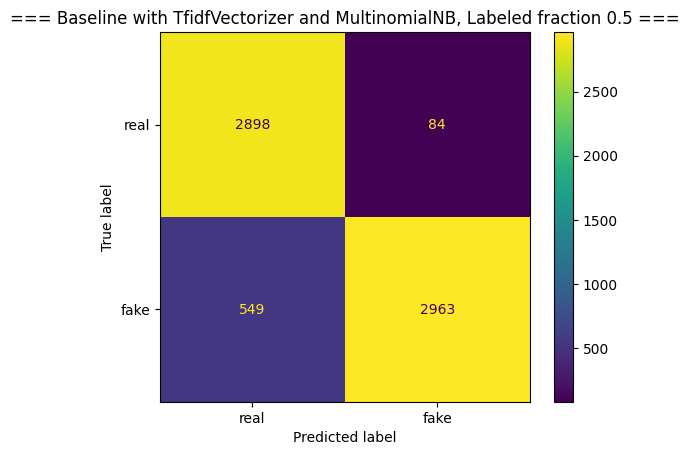

ROC-AUC: 0.9726
PR-AUC: 0.9767


=== Computing TF-IDF ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=9624, R_N=9624, leftover=6198
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/30 - Loss: 0.6350
Epoch 20/30 - Loss: 0.5739
Epoch 30/30 - Loss: 0.5313
=== Evaluation on test set ===


=== Keywords attention PU-LP with TFIDF, Labeled fraction 0.5 ===
              precision    recall  f1-score   support

        real     0.7875    0.7492    0.7678      2982
        fake     0.7955    0.8283    0.8115      3512

    accuracy                         0.7920      6494
   macro avg     0.7915    0.7887    0.7897      6494
weighted avg     0.7918    0.7920    0.7915      6494



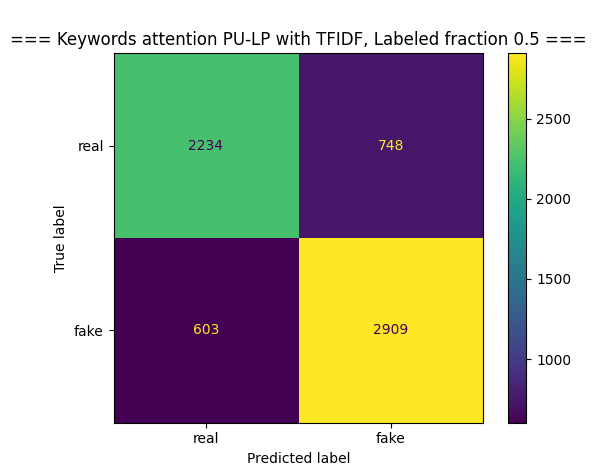



=== Training Doc2Vec ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=9624, R_N=9624, leftover=6198
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/50 - Loss: 0.6016
Epoch 20/50 - Loss: 0.5737
Epoch 30/50 - Loss: 0.5511
Epoch 40/50 - Loss: 0.5334
Epoch 50/50 - Loss: 0.5197
=== Evaluation on test set ===


=== Keywords attention PU-LP with Doc2Vec, Labeled fraction 0.5 ===
              precision    recall  f1-score   support

        real     0.8323    0.9373    0.8817      2982
        fake     0.9404    0.8397    0.8872      3512

    accuracy                         0.8845      6494
   macro avg     0.8864    0.8885    0.8844      6494
weighted avg     0.8908    0.8845    0.8847      6494



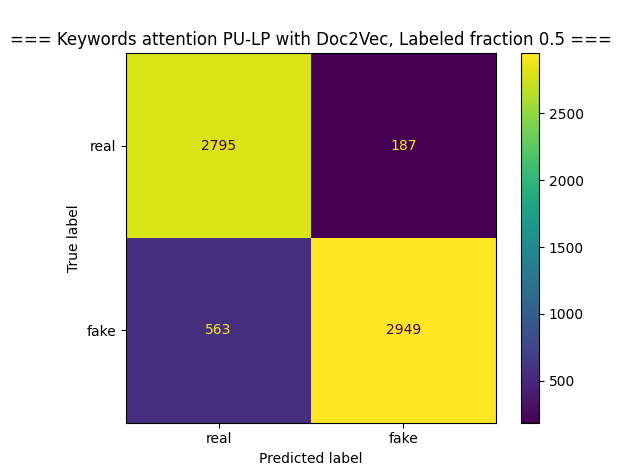




=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction 0.4 ===
              precision    recall  f1-score   support

        real     0.8283    0.9708    0.8939      2982
        fake     0.9710    0.8292    0.8945      3512

    accuracy                         0.8942      6494
   macro avg     0.8997    0.9000    0.8942      6494
weighted avg     0.9055    0.8942    0.8942      6494



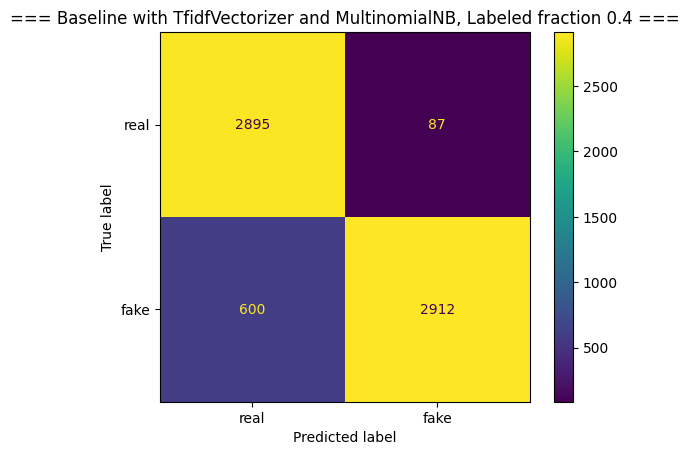

ROC-AUC: 0.9709
PR-AUC: 0.9754


=== Computing TF-IDF ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=7699, R_N=7699, leftover=11453
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/30 - Loss: 0.6105
Epoch 20/30 - Loss: 0.5511
Epoch 30/30 - Loss: 0.5113
=== Evaluation on test set ===


=== Keywords attention PU-LP with TFIDF, Labeled fraction 0.4 ===
              precision    recall  f1-score   support

        real     0.8228    0.7757    0.7985      2982
        fake     0.8184    0.8582    0.8378      3512

    accuracy                         0.8203      6494
   macro avg     0.8206    0.8169    0.8182      6494
weighted avg     0.8204    0.8203    0.8198      6494



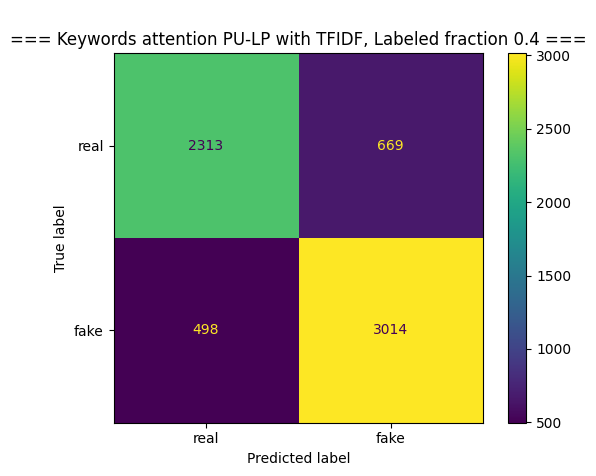



=== Training Doc2Vec ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=7699, R_N=7699, leftover=11453
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/50 - Loss: 0.5732
Epoch 20/50 - Loss: 0.5464
Epoch 30/50 - Loss: 0.5234
Epoch 40/50 - Loss: 0.5116
Epoch 50/50 - Loss: 0.4999
=== Evaluation on test set ===


=== Keywords attention PU-LP with Doc2Vec, Labeled fraction 0.4 ===
              precision    recall  f1-score   support

        real     0.9215    0.9249    0.9232      2982
        fake     0.9360    0.9331    0.9346      3512

    accuracy                         0.9293      6494
   macro avg     0.9288    0.9290    0.9289      6494
weighted avg     0.9293    0.9293    0.9293      6494



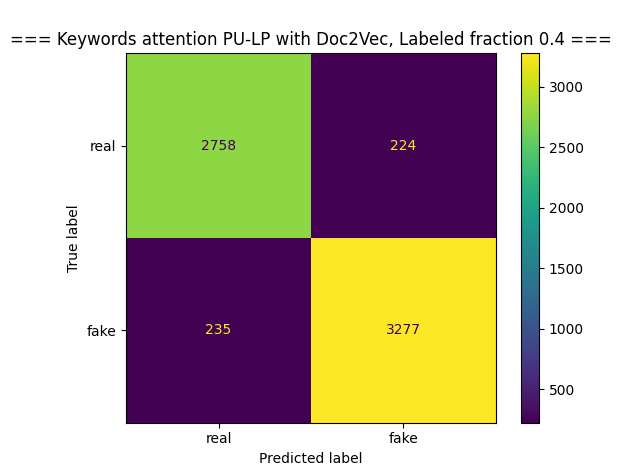




=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction 0.3 ===
              precision    recall  f1-score   support

        real     0.8209    0.9728    0.8904      2982
        fake     0.9726    0.8198    0.8897      3512

    accuracy                         0.8901      6494
   macro avg     0.8968    0.8963    0.8901      6494
weighted avg     0.9030    0.8901    0.8900      6494



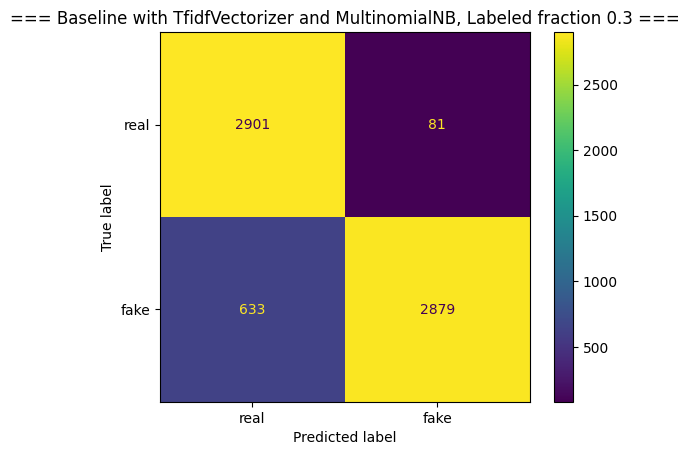

ROC-AUC: 0.9706
PR-AUC: 0.9750


=== Computing TF-IDF ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=5772, R_N=5772, leftover=16712
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/30 - Loss: 0.6109
Epoch 20/30 - Loss: 0.5407
Epoch 30/30 - Loss: 0.4972
=== Evaluation on test set ===


=== Keywords attention PU-LP with TFIDF, Labeled fraction 0.3 ===
              precision    recall  f1-score   support

        real     0.8199    0.7924    0.8059      2982
        fake     0.8286    0.8522    0.8403      3512

    accuracy                         0.8248      6494
   macro avg     0.8243    0.8223    0.8231      6494
weighted avg     0.8246    0.8248    0.8245      6494



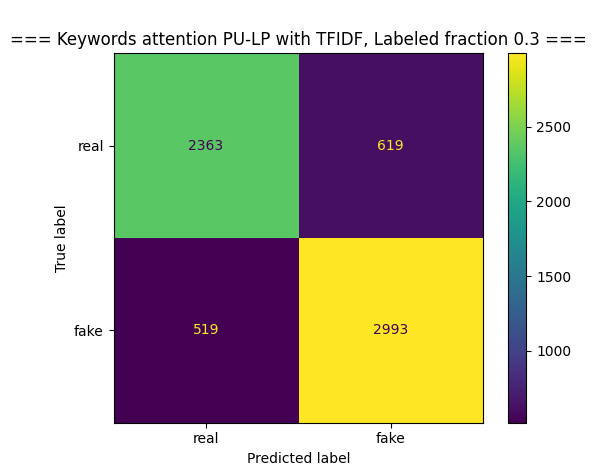



=== Training Doc2Vec ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=5772, R_N=5772, leftover=16712
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/50 - Loss: 0.5538
Epoch 20/50 - Loss: 0.5252
Epoch 30/50 - Loss: 0.5100
Epoch 40/50 - Loss: 0.4962
Epoch 50/50 - Loss: 0.4900
=== Evaluation on test set ===


=== Keywords attention PU-LP with Doc2Vec, Labeled fraction 0.3 ===
              precision    recall  f1-score   support

        real     0.9300    0.9182    0.9241      2982
        fake     0.9313    0.9413    0.9363      3512

    accuracy                         0.9307      6494
   macro avg     0.9306    0.9298    0.9302      6494
weighted avg     0.9307    0.9307    0.9307      6494



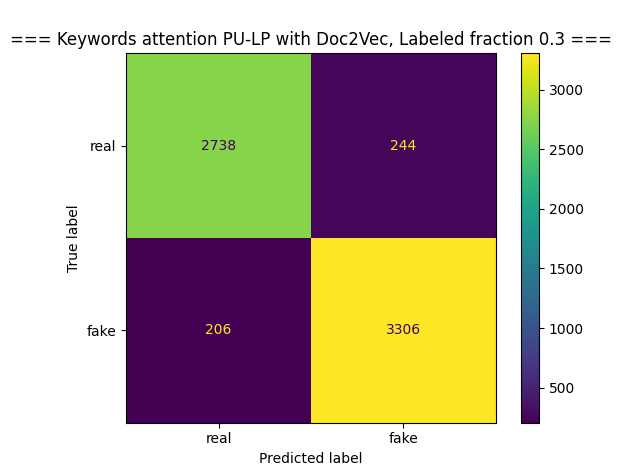




=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction 0.2 ===
              precision    recall  f1-score   support

        real     0.8014    0.9742    0.8794      2982
        fake     0.9732    0.7950    0.8751      3512

    accuracy                         0.8773      6494
   macro avg     0.8873    0.8846    0.8772      6494
weighted avg     0.8943    0.8773    0.8771      6494



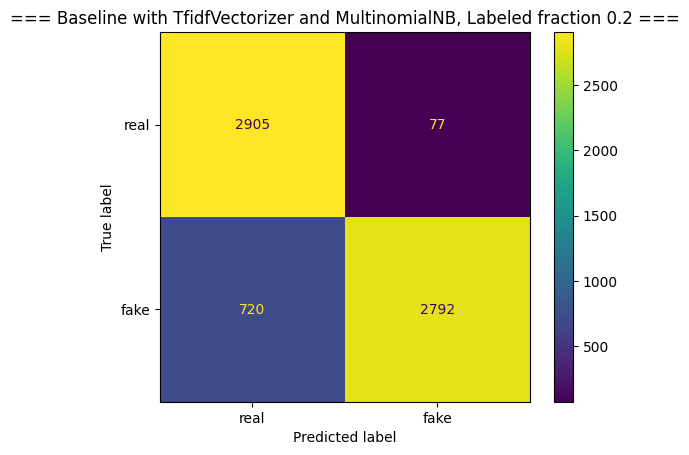

ROC-AUC: 0.9677
PR-AUC: 0.9725


=== Computing TF-IDF ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=3848, R_N=3848, leftover=21965
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/30 - Loss: 0.6252
Epoch 20/30 - Loss: 0.5516
Epoch 30/30 - Loss: 0.5086
=== Evaluation on test set ===


=== Keywords attention PU-LP with TFIDF, Labeled fraction 0.2 ===
              precision    recall  f1-score   support

        real     0.7979    0.7985    0.7982      2982
        fake     0.8288    0.8283    0.8285      3512

    accuracy                         0.8146      6494
   macro avg     0.8133    0.8134    0.8134      6494
weighted avg     0.8146    0.8146    0.8146      6494



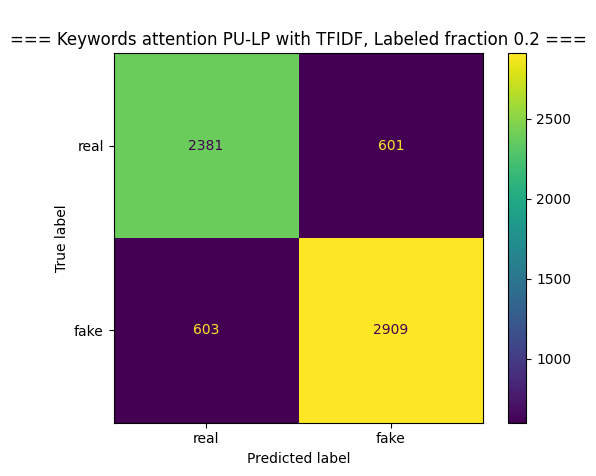



=== Training Doc2Vec ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=3848, R_N=3848, leftover=21965
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/50 - Loss: 0.5823
Epoch 20/50 - Loss: 0.5477
Epoch 30/50 - Loss: 0.5343
Epoch 40/50 - Loss: 0.5244
Epoch 50/50 - Loss: 0.5167
=== Evaluation on test set ===


=== Keywords attention PU-LP with Doc2Vec, Labeled fraction 0.2 ===
              precision    recall  f1-score   support

        real     0.9499    0.8702    0.9083      2982
        fake     0.8971    0.9610    0.9280      3512

    accuracy                         0.9193      6494
   macro avg     0.9235    0.9156    0.9181      6494
weighted avg     0.9213    0.9193    0.9189      6494



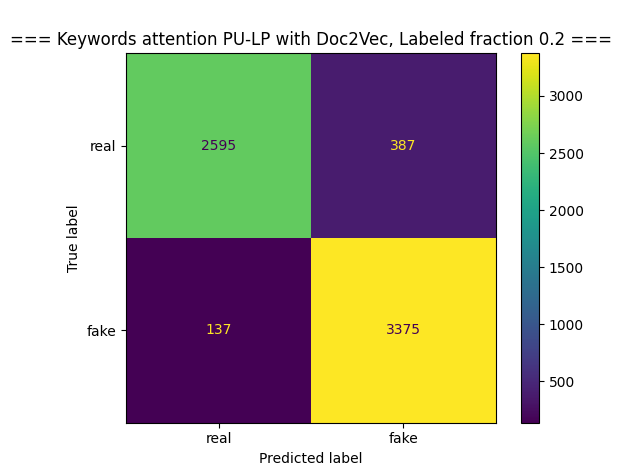




=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction 0.1 ===
              precision    recall  f1-score   support

        real     0.7601    0.9762    0.8547      2982
        fake     0.9733    0.7383    0.8397      3512

    accuracy                         0.8476      6494
   macro avg     0.8667    0.8573    0.8472      6494
weighted avg     0.8754    0.8476    0.8466      6494



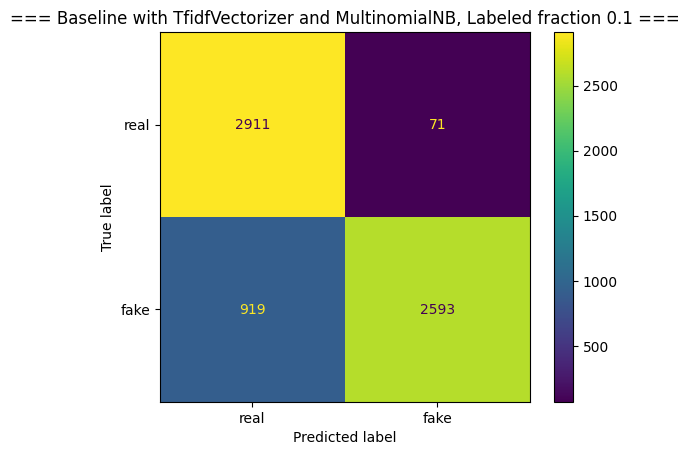

ROC-AUC: 0.9627
PR-AUC: 0.9679


=== Computing TF-IDF ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=1924, R_N=1924, leftover=27218
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/30 - Loss: 0.6043
Epoch 20/30 - Loss: 0.5462
Epoch 30/30 - Loss: 0.4910
=== Evaluation on test set ===


=== Keywords attention PU-LP with TFIDF, Labeled fraction 0.1 ===
              precision    recall  f1-score   support

        real     0.8924    0.4980    0.6393      2982
        fake     0.6901    0.9490    0.7991      3512

    accuracy                         0.7419      6494
   macro avg     0.7912    0.7235    0.7192      6494
weighted avg     0.7830    0.7419    0.7257      6494



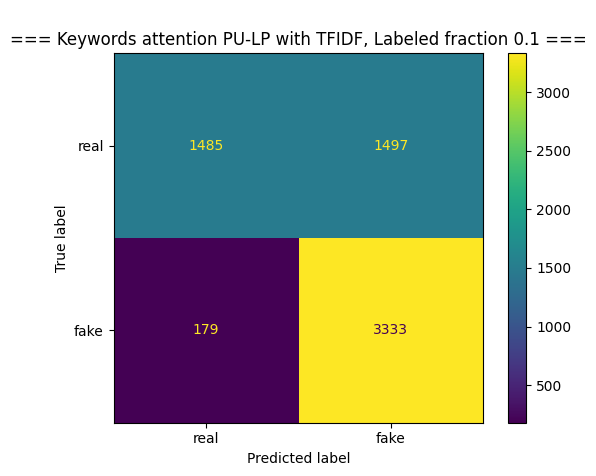



=== Training Doc2Vec ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=1924, R_N=1924, leftover=27218
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/50 - Loss: 0.5811
Epoch 20/50 - Loss: 0.5426
Epoch 30/50 - Loss: 0.5336
Epoch 40/50 - Loss: 0.5226
Epoch 50/50 - Loss: 0.5156
=== Evaluation on test set ===


=== Keywords attention PU-LP with Doc2Vec, Labeled fraction 0.1 ===
              precision    recall  f1-score   support

        real     0.9835    0.6405    0.7758      2982
        fake     0.7645    0.9909    0.8631      3512

    accuracy                         0.8300      6494
   macro avg     0.8740    0.8157    0.8194      6494
weighted avg     0.8651    0.8300    0.8230      6494



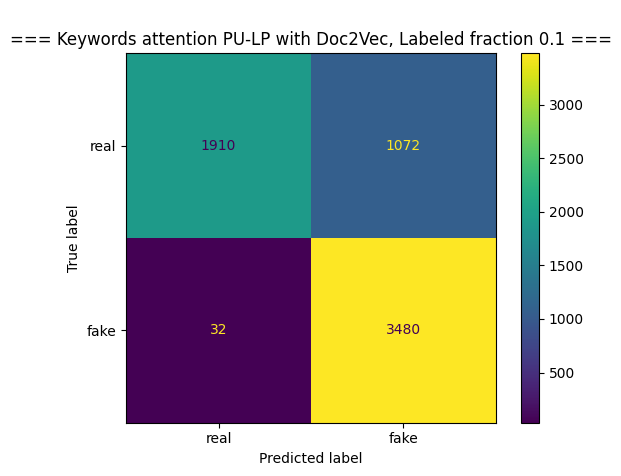

In [10]:
dataset_file = "data/processed.csv"
fraction = [0.5, 0.4, 0.3, 0.2, 0.1]
# fraction = [0.3]


for fraction in fraction:
    data = KAFNData(
        csv_path=dataset_file, random_state=42, fraction_fake_labeled=fraction, test_size=0.2
    )
    test_baseline(data)
    test_pulp_tfidfvectorizer_pipeline(data)
    test_pulp_doc2vec_pipeline(data)
    del data
    gc.collect()